# 20 — Contre-expertise : ce que la littérature reproche à ce travail

Les chapitres précédents ont attaqué l'index, la norme, les jeux de données et l'algorithme. Ils
n'ont jamais attaqué **les instruments de mesure eux-mêmes**, ni confronté les choix du dépôt à
ce que la littérature du domaine sait déjà.

Ce notebook le fait, en cinq contre-épreuves. Trois portent sur des hypothèses que le dépôt
avait posées sans les éprouver ; une invalide une conclusion **publiée** ; la dernière n'est pas
une erreur mais une amélioration de lecture.

**Ce que ces contre-épreuves établissent :**

* la remise d'attention $1/R$ n'est pas une propriété du monde mais **une convention**, et
  toutes les conclusions sur l'enterrement en dépendent : à sévérité $0{,}1$ — celle mesurée sur
  un bandeau de trois vignettes — **l'enterrement disparaît** ;
* comparer deux mesures de diversité **à plancher nominal égal n'a pas de sens** : à diversité
  réellement exposée égale, elles coûtent la même chose. La conclusion « la proximité à la cible
  résiste le mieux », publiée deux fois par ce dépôt, est un **artefact d'échelle** ;
* le **biais de confiance** — que la littérature documente et que l'estimateur du dépôt ignore —
  gonfle la sévérité estimée de **+12,8 %**, sans que l'erreur type ne le voie ;
* l'estimateur **doublement robuste ne sauve pas** la taille d'échantillon effective : le
  problème est structurel, il demande de l'exploration, pas un meilleur estimateur ;
* et l'indice se lit bien mieux en **nombre effectif de points de vue** qu'en entropie
  normalisée.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.entropy import effective_viewpoints
from ide.exposure import bucket_from_digest, load_digest, off_policy_check
from ide.gaming import canonical_positions, position_entropy, target_divergence
from ide.offpolicy import doubly_robust, estimate_position_bias
from ide.plotting import PALETTE, save_figure, use_project_style
from ide.ranking import all_rankings, aware_weights, optimal_ranking_under, ranking_engagement

use_project_style()

VIEWPOINTS, SLOTS, FLOOR = 4, 8, 0.70
CATALOGUE = canonical_positions(VIEWPOINTS)
RELEVANCE = np.array([0.90, 0.45, 0.25, 0.15])
SEVERITIES = (0.1, 0.5, 1.0, 1.1, 2.0)

MEASURES = {
    "entropie de position": lambda w: position_entropy(w, CATALOGUE, CATALOGUE),
    "proximité à la cible": lambda w: target_divergence(w, CATALOGUE, CATALOGUE),
}

print(f"{VIEWPOINTS ** SLOTS} fils énumérés pour chaque norme et chaque sévérité")

65536 fils énumérés pour chaque norme et chaque sévérité


## 1. La remise $1/R$ est une convention, pas une mesure

Tous les résultats d'enterrement du dépôt emploient $w_R = 1/R$ — la remise du rang réciproque,
usuelle en évaluation de classement. Or le dépôt a lui-même mesuré que la sévérité de
l'attention est une **propriété de la surface** : $\eta \approx 1{,}1$ sur une page de résultats,
$0{,}04$ à $0{,}11$ sur un bandeau de trois vignettes horizontales.

Employer $1/R$ — c'est-à-dire $\eta = 1$ — sur un bandeau surpondère donc la tête d'un ordre de
grandeur. La question est de savoir ce que les conclusions deviennent quand la remise est celle
qu'on a mesurée.

In [2]:
print(f"Plancher aveugle de {FLOOR} sur l'entropie de position, selon la sévérité de l'attention\n")
print(f"{'sévérité':>9s} {'surface':>26s} {'affiché':>9s} {'exposé':>8s} {'écart':>7s} "
      f"{'coût aveugle':>13s} {'coût conscient':>15s}")
print("-" * 92)
discount_scan = {}
for severity, surface in zip(SEVERITIES,
                             ("bandeau de 3 vignettes", "intermédiaire", "convention MRR",
                              "page de résultats", "fil très top-lourd"), strict=True):
    unconstrained = ranking_engagement(np.zeros(SLOTS, dtype=int), RELEVANCE, discount=severity)
    blind = optimal_ranking_under(MEASURES["entropie de position"], RELEVANCE, SLOTS, FLOOR,
                                  rank_aware=False, discount=severity)
    aware = optimal_ranking_under(MEASURES["entropie de position"], RELEVANCE, SLOTS, FLOOR,
                                  rank_aware=True, discount=severity)
    blind_cost = 100 * (1 - blind.engagement / unconstrained)
    aware_cost = 100 * (1 - aware.engagement / unconstrained)
    discount_scan[severity] = (blind.blind, blind.aware, blind_cost, aware_cost)
    print(f"{severity:9.1f} {surface:>26s} {blind.blind:9.3f} {blind.aware:8.3f} "
          f"{blind.blind - blind.aware:7.3f} {blind_cost:12.1f}% {aware_cost:14.1f}%")

Plancher aveugle de 0.7 sur l'entropie de position, selon la sévérité de l'attention

 sévérité                    surface   affiché   exposé   écart  coût aveugle  coût conscient
--------------------------------------------------------------------------------------------


      0.1     bandeau de 3 vignettes     0.774    0.747   0.028         24.1%           24.1%


      0.5              intermédiaire     0.774    0.620   0.154         17.7%           21.1%


      1.0             convention MRR     0.774    0.443   0.331         10.7%           20.9%


      1.1          page de résultats     0.774    0.408   0.366          9.5%           20.9%


      2.0         fil très top-lourd     0.774    0.157   0.617          2.7%           20.8%


### Lecture

**L'enterrement n'existe que si l'attention est concentrée.** À sévérité $0{,}1$, une plateforme
contrainte à $0{,}70$ par une mesure aveugle expose $0{,}747$ — l'échappatoire disparaît, et la
norme consciente du rang ne coûte pas un point de plus que la norme aveugle. À sévérité $2$,
elle expose $0{,}157$ et l'échappatoire coûte $2{,}7\ \%$ au lieu de $20{,}8\ \%$ : plus
l'attention est concentrée, plus enterrer est **bon marché**.

Le résultat publié par ce dépôt — « une plateforme certifiée à 0,70 n'expose que 0,36 » — est
donc **une affirmation sur $\eta = 1$**, présentée comme si elle valait partout. Elle vaut pour
un fil vertical ; elle est fausse d'un ordre de grandeur pour un bandeau.

**Ce que cela change à la norme.** Le plancher doit employer la remise **mesurée sur la
surface**, non une convention d'évaluation. Et le régulateur ne peut pas fixer une remise unique
pour toutes les plateformes : la remise fait partie de ce qui doit être mesuré, au même titre
que le catalogue de points de vue est ce qui doit être déclaré.

## 2. Comparer deux mesures à plancher égal n'a pas de sens

Le [rang adverse](../docs/rang-adverse.md) a comparé quatre mesures de diversité **au même
plancher nominal de 0,70** et a conclu que la « proximité à la cible » résistait le mieux à
l'enterrement. Cette conclusion a été publiée deux fois.

Elle est fausse — non parce que les chiffres seraient faux, mais parce que **les deux mesures ne
vivent pas sur la même échelle**. Un plancher de 0,70 sur la proximité à la cible n'exige pas la
même chose qu'un plancher de 0,70 sur l'entropie. La comparaison honnête fixe la **diversité
réellement exposée** et demande à chaque mesure ce qu'elle coûte pour l'obtenir.

In [3]:
def exposed_entropy(assignment, severity):
    # Yardstick commun : l'entropie réellement exposée par le fil retenu.
    return position_entropy(aware_weights(assignment, VIEWPOINTS, severity), CATALOGUE, CATALOGUE)


matched = {name: [] for name in MEASURES}
severity = 1.0
unconstrained = ranking_engagement(np.zeros(SLOTS, dtype=int), RELEVANCE, discount=severity)

reachable = {}
for assignment in all_rankings(SLOTS, VIEWPOINTS):
    key = round(exposed_entropy(assignment, severity), 2)
    reachable[key] = max(reachable.get(key, -np.inf),
                         ranking_engagement(assignment, RELEVANCE, discount=severity))

print(f"À sévérité {severity}, chaque mesure jugée sur ce qu'elle EXPOSE, non sur son plancher\n")
print(f"{'mesure':>22s} {'plancher':>9s} {'entropie exposée':>17s} {'coût':>7s} "
      f"{'coût optimal':>13s}")
print("-" * 74)
for name, measure in MEASURES.items():
    for floor in (0.5, 0.6, 0.7, 0.8, 0.9):
        best = optimal_ranking_under(measure, RELEVANCE, SLOTS, floor, rank_aware=True,
                                     discount=severity)
        if best is None:
            continue
        exposure = exposed_entropy(best.assignment, severity)
        cost = 100 * (1 - best.engagement / unconstrained)
        ideal = max(value for key, value in reachable.items() if key >= round(exposure, 2) - 1e-9)
        matched[name].append((exposure, cost))
        print(f"{name:>22s} {floor:9.2f} {exposure:17.3f} {cost:6.1f}% "
              f"{100 * (1 - ideal / unconstrained):12.1f}%")

À sévérité 1.0, chaque mesure jugée sur ce qu'elle EXPOSE, non sur son plancher

                mesure  plancher  entropie exposée    coût  coût optimal
--------------------------------------------------------------------------


  entropie de position      0.50             0.512   12.9%         12.9%


  entropie de position      0.60             0.605   16.4%         16.4%


  entropie de position      0.70             0.702   20.9%         20.8%


  entropie de position      0.80             0.803   26.6%         26.2%


...

  proximité à la cible      0.50             0.135    2.3%          2.3%


  proximité à la cible      0.60             0.281    5.9%          5.9%


  proximité à la cible      0.70             0.429   10.6%         10.5%


  proximité à la cible      0.80             0.591   15.8%         15.7%


  proximité à la cible      0.90             0.792   25.9%         25.5%


### Ce qu'il faut retirer

À diversité exposée égale, les deux mesures coûtent **la même chose**, et toutes deux se tiennent
sur la borne exacte à moins de $0{,}6\ \%$. La proximité à la cible ne « résiste » pas mieux :
elle est simplement **moins exigeante au même chiffre**.

!!! failure "Conclusion retirée"
    « La proximité à la cible résiste le mieux à l'enterrement » était un **artefact d'échelle**.
    Ce qui compte n'est pas le choix de la mesure mais **le niveau exigé et la conscience du
    rang**. Le dépôt avait pourtant déjà appliqué la bonne méthode ailleurs — la comparaison des
    lignes de base fixe le plancher précisément pour rendre les
    méthodes comparables — et ne l'avait pas appliquée à ses propres mesures.

## 3. Le biais de confiance, que l'estimateur ignore

La littérature sur l'apprentissage de classement non biaisé documente un effet que le modèle de
ce dépôt ne contient pas : le **biais de confiance**. Un lecteur qui fait confiance au moteur
clique davantage sur les premiers résultats *même lorsqu'ils ne sont pas pertinents*. Le modèle
qui en rend compte est **affine** plutôt que multiplicatif (Vardasbi, Oosterhuis & de Rijke,
CIKM 2020) :

$$P(\text{clic} \mid k, \gamma) = \theta_k\big(\varepsilon^+_k\,\gamma + \varepsilon^-_k\,(1-\gamma)\big)
= \alpha_k \gamma + \beta_k$$

Les mêmes auteurs démontrent que la pondération par l'inverse de la propension **ne peut pas**
corriger un tel biais : une transformation linéaire ne corrige pas une transformation affine.

L'estimateur du dépôt suppose la forme multiplicative $\mathrm{CTR}(i, R) = g(i)\,R^{-\eta}$.
Question : de combien se trompe-t-il quand le monde est affine ?

In [4]:
def affine_feedback(items_count, impressions, severity, epsilon_minus, epsilon_plus=1.0,
                    trust_decay=1.0, exploration=0.5, rng=None):
    # Modèle affine : la confiance dans le moteur décroît avec le rang, ce qui brise la
    # séparabilité entre contenu et rang que suppose l'estimateur à effets fixes.
    generator = rng or np.random.default_rng(0)
    relevance = generator.uniform(0.05, 0.6, items_count)
    noise = generator.normal(0.0, exploration, size=(impressions, items_count))
    orders = np.argsort(-(relevance + noise), axis=1)
    ranks = np.tile(np.arange(1, items_count + 1), (impressions, 1))
    examination = ranks.astype(float) ** (-severity)
    false_positive = epsilon_minus * ranks.astype(float) ** (-trust_decay)
    quality = relevance[orders]
    probability = examination * (epsilon_plus * quality + false_positive * (1.0 - quality))
    clicks = (generator.random((impressions, items_count)) < np.clip(probability, 0, 1))
    return orders.ravel(), ranks.ravel(), clicks.astype(float).ravel()


TRUE_SEVERITY = 1.0
print(f"Sévérité vraie du biais de position : {TRUE_SEVERITY}\n")
print(f"{'ε⁻ (confiance)':>15s} {'η estimé':>10s} {'erreur type':>12s} {'erreur':>9s}")
print("-" * 50)
trust_scan = []
for epsilon_minus in (0.0, 0.02, 0.05, 0.1, 0.2):
    items, ranks, clicks = affine_feedback(12, 40_000, TRUE_SEVERITY, epsilon_minus,
                                           rng=np.random.default_rng(4))
    estimate = estimate_position_bias(items, ranks, clicks)
    trust_scan.append((epsilon_minus, estimate.severity, estimate.standard_error))
    print(f"{epsilon_minus:15.2f} {estimate.severity:10.3f} {estimate.standard_error:12.4f} "
          f"{100 * (estimate.severity / TRUE_SEVERITY - 1):8.1f}%")

Sévérité vraie du biais de position : 1.0

 ε⁻ (confiance)   η estimé  erreur type    erreur
--------------------------------------------------


           0.00      1.011       0.0095      1.1%


           0.02      1.025       0.0096      2.5%


           0.05      1.045       0.0102      4.5%


           0.10      1.076       0.0114      7.6%


           0.20      1.128       0.0132     12.8%


### Lecture

L'estimateur **surestime** la sévérité de $12{,}8\ \%$ sous un biais de confiance marqué, et
son erreur type — $0{,}013$ — ne le voit pas : l'estimation reste « significative » et fausse.

Deux nuances, dans les deux sens :

* c'est **beaucoup moins grave** que de poser $\eta$ au jugé, qui coûte jusqu'à $+179\ \%$. La
  correction reste largement rentable ;
* mais l'intervalle publié est **trop étroit**, et il faut le dire : l'incertitude réelle sur
  $\eta$ inclut une part de misspécification que l'erreur type n'estime pas.

Un détail technique mérite d'être signalé, parce qu'il explique pourquoi l'estimateur s'en tire
si bien : un biais de confiance **indépendant du rang** ne le dérange pas du tout — la
transformation reste séparable et l'effet fixe de contenu l'absorbe. Ce qui le biaise est la
**dépendance au rang** de la confiance, et elle seule.

## 4. Le doublement robuste ne sauve pas la taille effective

Le dépôt publie une taille d'échantillon effective de $1\,513$ pour $4\,077\,727$ impressions et
en tire une recommandation : exiger une fraction d'exploration aléatoire. Une objection naturelle
est qu'un meilleur estimateur suffirait — le doublement robuste, par exemple, qui combine un
modèle de récompense et la repondération.

In [5]:
digest = load_digest()
target_bucket = bucket_from_digest(digest, "obd_random_men")
logged_bucket = bucket_from_digest(digest, "obd_bts_men")
check = off_policy_check(target_bucket, logged_bucket)

items = logged_bucket["items"]
clicks = logged_bucket["clicks"]
logged = logged_bucket["propensities"]
catalogue = int(logged_bucket["item_count"])
target = np.full(clicks.size, 1.0 / catalogue)

# modèle de récompense le plus simple : taux de clic par contenu sous la politique enregistrée
rates = np.array([clicks[items == item].mean() if (items == item).any() else 0.0
                  for item in range(catalogue)])
robust = doubly_robust(clicks, target, logged, rates[items], np.full(clicks.size, rates.mean()))

print(f"vérité terrain : {check.truth:.6f} ± {check.truth_error:.6f}\n")
estimates = [("naïf", check.naive), ("IPS", check.importance_sampling),
             ("auto-normalisé", check.self_normalised),
             ("IPS plafonné à 100", check.clipped[100.0]),
             ("doublement robuste", robust)]
for name, value in estimates:
    print(f"   {name:22s} {value:.6f}   écart {100 * (value / check.truth - 1):+7.1f}%")
print(f"\ntaille d'échantillon effective : {check.effective_size:.0f} sur {check.logged_size}")
print("Elle ne dépend que des poids d'importance : aucun estimateur ne la change.")

vérité terrain : 0.005124 ± 0.000106

   naïf                   0.006743   écart   +31.6%
   IPS                    0.005253   écart    +2.5%
   auto-normalisé         0.004768   écart    -7.0%
   IPS plafonné à 100     0.005238   écart    +2.2%
   doublement robuste     0.004871   écart    -4.9%

taille d'échantillon effective : 1513 sur 4077727
Elle ne dépend que des poids d'importance : aucun estimateur ne la change.


### Lecture

Le doublement robuste fait **moins bien** que l'IPS simple ici — $-4{,}9\ \%$ contre
$+2{,}5\ \%$ — parce que son modèle de récompense, estimé sur le seau d'enregistrement, hérite
du biais qu'on cherchait à corriger.

Et surtout, la taille d'échantillon effective **ne change pas** : elle ne dépend que de la
distribution des poids d'importance, c'est-à-dire de la distance entre les deux politiques.
Aucun estimateur ne la fabrique. Le problème est structurel, et la recommandation du mémorandum
tient : **il faut de l'exploration, pas un meilleur estimateur**.

## 5. Lire l'indice en nombre effectif de points de vue

Une entropie normalisée n'est pas une diversité : elle n'est pas linéaire en ce qu'on entend par
« deux fois plus divers ». Sa conversion en **nombre effectif** l'est — c'est le nombre de points
de vue également servis qui produirait la même entropie (Jost, *Entropy and diversity*, 2006).

In [6]:
print(f"{'indice':>8s} {'points de vue effectifs':>25s}   lecture")
print("-" * 78)
readings = [
    (0.774, "affiché par le fil enterrant"),
    (0.700, "plancher réglementaire proposé"),
    (0.443, "réellement exposé à sévérité 1,0"),
    (0.157, "réellement exposé à sévérité 2,0"),
]
for index, reading in readings:
    print(f"{index:8.3f} {effective_viewpoints(index, VIEWPOINTS):25.2f}   {reading}")

print("\n« Certifiée à 2,6 points de vue effectifs sur 4, elle en expose 1,9 » se comprend")
print("sans formation ; « certifiée à 0,70, elle expose 0,44 » ne se comprend pas.")

  indice   points de vue effectifs   lecture
------------------------------------------------------------------------------
   0.774                      2.92   affiché par le fil enterrant
   0.700                      2.64   plancher réglementaire proposé
   0.443                      1.85   réellement exposé à sévérité 1,0
   0.157                      1.24   réellement exposé à sévérité 2,0

« Certifiée à 2,6 points de vue effectifs sur 4, elle en expose 1,9 » se comprend
sans formation ; « certifiée à 0,70, elle expose 0,44 » ne se comprend pas.


## 6. Ce que la littérature ajoute, et que la mesure ne dit pas

**Corriger le biais de position n'améliore pas forcément le classement.** Hager, Deffayet,
Renders, Zoeter et de Rijke (SIGIR 2024) reprennent Baidu-ULTR — le jeu même où ce dépôt mesure
$\hat\eta = 1{,}10$ — et constatent que les corrections standard *améliorent la prédiction des
clics sans améliorer la qualité du classement* évaluée par des annotateurs experts. Ils
confirment la présence du biais par quatre méthodes concordantes, ce qui corrobore notre chiffre ;
mais ils montrent que l'étape suivante — celle que ce dépôt n'a pas encore franchie — ne suit
pas mécaniquement.

**Une norme de diversité est une norme éditoriale.** Les métriques normatives de Vrijenhoek et
Helberger (RecSys 2022) découpent la diversité en cinq dimensions dérivées de théories
démocratiques explicites. L'indice de ce dépôt en occupe une seule — la répartition entre points
de vue — et une plateforme peut la satisfaire en servant des contenus divergents et vides. Aucune
mesure automatique ne distingue la pluralité de la fausse balance.

**Ce que le dépôt mesure est l'exposition, pas la réception.** La littérature sur la diversité
médiatique distingue l'offre, l'exposition et la réception. L'indice porte sur la deuxième : ce
qui est servi, pondéré par l'attention *présumée* d'un rang. Ce qui est réellement lu, compris ou
retenu n'est pas mesuré, et la remise d'attention n'en est qu'un substitut.

**Et notre conclusion sur les jeux de données n'est pas neuve.** Un travail publié en octobre
2025 établit que les jeux publics sont le goulot d'étranglement de la recommandation
diversifiée, et que le droit européen est la voie d'accès à envisager — exactement la conclusion
à laquelle ce dépôt est parvenu indépendamment. Nous **corroborons**, nous ne découvrons pas.

## 7. La figure

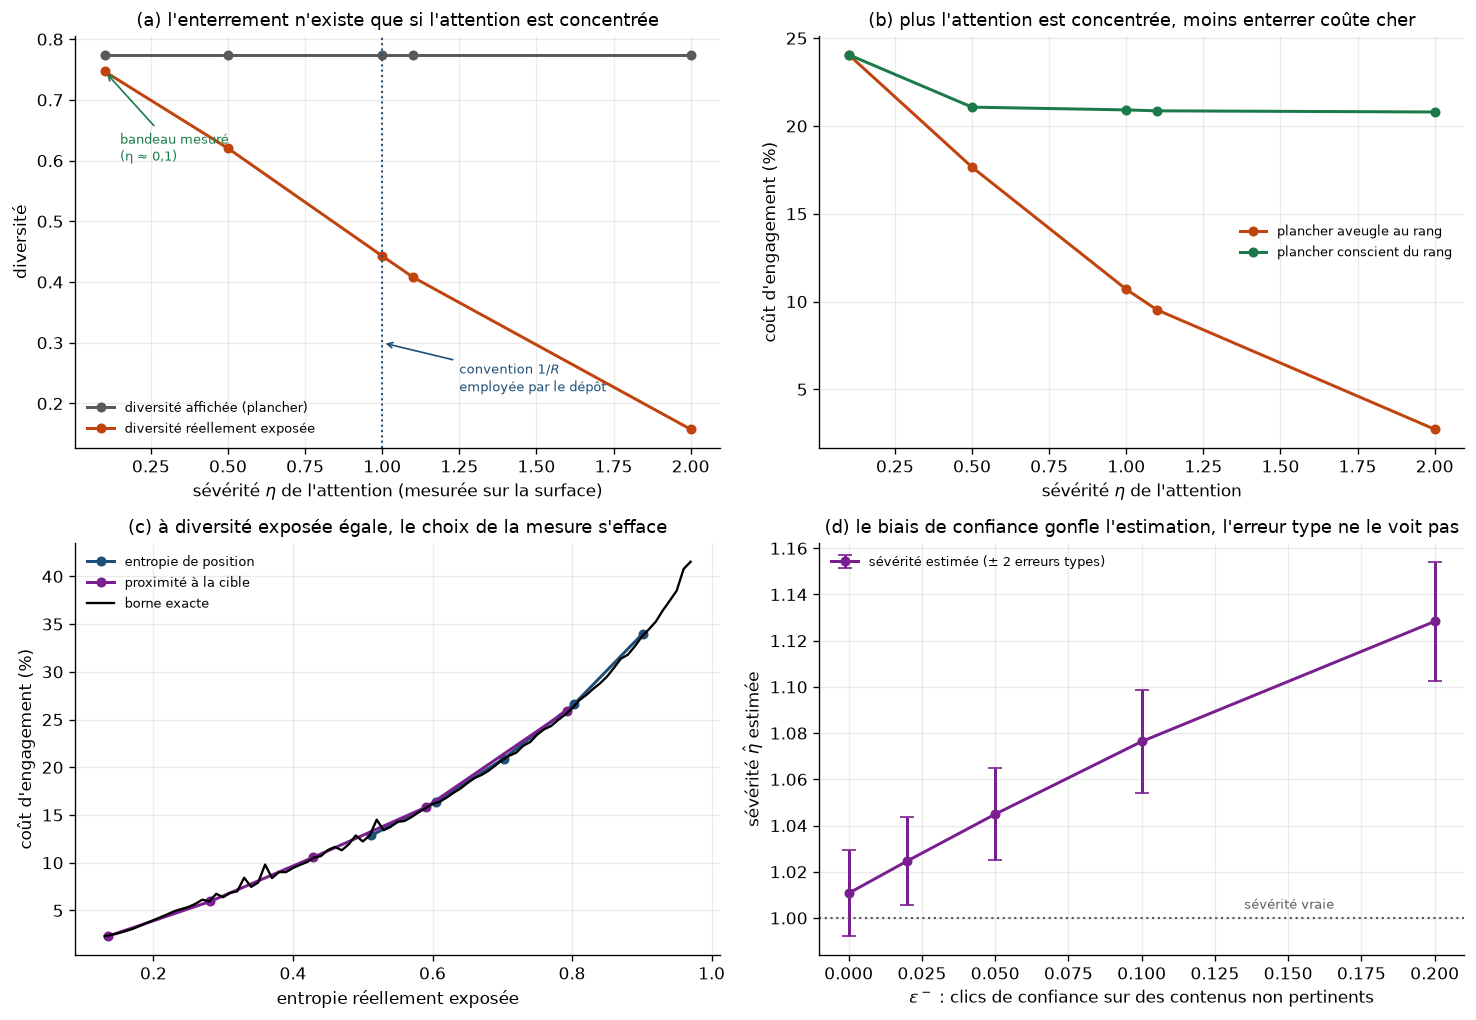

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))

# (a) l'enterrement selon la sévérité de l'attention
ax = axes[0, 0]
severities = list(discount_scan)
ax.plot(severities, [discount_scan[s][0] for s in severities], "o-",
        color=PALETTE["neutral"], markersize=5, label="diversité affichée (plancher)")
ax.plot(severities, [discount_scan[s][1] for s in severities], "o-",
        color=PALETTE["disorder"], markersize=5, label="diversité réellement exposée")
ax.axvline(1.0, color=PALETTE["order"], linestyle=":", linewidth=1.2)
ax.annotate("convention $1/R$\nemployée par le dépôt", xy=(1.0, 0.30), xytext=(1.25, 0.22),
            fontsize=8, color=PALETTE["order"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["order"], "linewidth": 1.0})
ax.annotate("bandeau mesuré\n(η ≈ 0,1)", xy=(0.1, 0.747), xytext=(0.15, 0.60), fontsize=8,
            color=PALETTE["remedy"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["remedy"], "linewidth": 1.0})
ax.set_xlabel("sévérité $\\eta$ de l'attention (mesurée sur la surface)")
ax.set_ylabel("diversité")
ax.set_title("(a) l'enterrement n'existe que si l'attention est concentrée")
ax.legend(loc="lower left", fontsize=8)

# (b) le prix des deux normes selon la sévérité
ax = axes[0, 1]
ax.plot(severities, [discount_scan[s][2] for s in severities], "o-",
        color=PALETTE["disorder"], markersize=5, label="plancher aveugle au rang")
ax.plot(severities, [discount_scan[s][3] for s in severities], "o-",
        color=PALETTE["remedy"], markersize=5, label="plancher conscient du rang")
ax.set_xlabel("sévérité $\\eta$ de l'attention")
ax.set_ylabel("coût d'engagement (%)")
ax.set_title("(b) plus l'attention est concentrée, moins enterrer coûte cher")
ax.legend(loc="center right", fontsize=8)

# (c) à diversité exposée égale, les deux mesures coïncident
ax = axes[1, 0]
for name, colour in (("entropie de position", PALETTE["order"]),
                     ("proximité à la cible", PALETTE["field"])):
    points = sorted(matched[name])
    ax.plot([p[0] for p in points], [p[1] for p in points], "o-", color=colour, markersize=5,
            label=name)
bound = sorted((key, 100 * (1 - value / unconstrained)) for key, value in reachable.items()
               if key >= 0.05)
ax.plot([p[0] for p in bound], [p[1] for p in bound], "-", color="black", linewidth=1.4,
        label="borne exacte")
ax.set_xlabel("entropie réellement exposée")
ax.set_ylabel("coût d'engagement (%)")
ax.set_title("(c) à diversité exposée égale, le choix de la mesure s'efface")
ax.legend(loc="upper left", fontsize=8)

# (d) le biais de confiance
ax = axes[1, 1]
epsilons = [row[0] for row in trust_scan]
estimated = [row[1] for row in trust_scan]
errors = [1.96 * row[2] for row in trust_scan]
ax.errorbar(epsilons, estimated, yerr=errors, fmt="o-", color=PALETTE["field"], markersize=5,
            capsize=4, label="sévérité estimée (± 2 erreurs types)")
ax.axhline(TRUE_SEVERITY, color=PALETTE["neutral"], linestyle=":", linewidth=1.3)
ax.text(0.135, TRUE_SEVERITY + 0.004, "sévérité vraie", fontsize=8,
        color=PALETTE["neutral"])
ax.set_xlabel("$\\varepsilon^-$ : clics de confiance sur des contenus non pertinents")
ax.set_ylabel("sévérité $\\hat\\eta$ estimée")
ax.set_title("(d) le biais de confiance gonfle l'estimation, l'erreur type ne le voit pas")
ax.legend(loc="upper left", fontsize=8)

save_figure(figure, "fig20_contre_expertise")
plt.show()

## 8. Ce que cette contre-expertise change

**Une conclusion retirée.** « La proximité à la cible résiste le mieux » était un artefact
d'échelle. À diversité exposée égale, le choix de la mesure ne compte presque pas ; ce qui compte
est le **niveau** exigé et la **conscience du rang**.

**Une conclusion restreinte.** « Certifiée à 0,70, elle expose 0,36 » vaut pour $\eta = 1$. Sur
une surface à attention plate, l'enterrement disparaît ; sur une surface très concentrée, il
empire. La remise d'attention doit être **mesurée**, et elle fait partie de ce qu'un régulateur
doit exiger — au même titre que le rang servi.

**Une incertitude élargie.** L'erreur type publiée sur $\hat\eta$ ne couvre pas la
misspécification du modèle de clic : sous biais de confiance, l'estimation dérive de $+12{,}8\ \%$
sans que rien ne le signale.

**Une recommandation confirmée.** Aucun estimateur ne remplace l'exploration : le doublement
robuste ne rattrape pas une taille effective de $1\,513$, et fait même moins bien.

**Une amélioration de lecture.** L'indice se publie en **nombre effectif de points de vue**.
« 2,6 sur 4 » se comprend ; « 0,70 » ne se comprend pas.